# Recreating the model from the paper by [Shah et al. (2022)](../../papers/2022Shah%20-%20Physics%20Informed%20Neural%20Networks%20As%20Solvers%20for%20the%20Time%20Dependent%20Schrödinger%20Equation.pdf)

<ul>
	<li> In this paper, they solve the Schrodinger equation for an electron trapped in a 1-D harmonic potential, using PINN</li>
	<li>Physics-informed neural networks (PINNs) are deep learning models that learn to solve partial differential equations (PDEs) like the Schrodinger equation by including the physical laws directly into the model’s loss function</li>
</ul>

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

#### They adopted Hartree atomic units (ℏ= me = 1), so energies are measured in Hartree and lengths in Bohr radii

In [2]:
hbar = 1
m = 1
omega = 1

x_min = -np.pi
x_max = np.pi
t_min = 0
t_max = 2 * np.pi

In [3]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS backend for Apple GPU acceleration!")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using cuda")
else:
    device = torch.device("cpu")
    print("Using CPU instead.")

Using cuda


### Neural network architecture

- Feed forward neural network
- **tanh** activation function:
	- the activation function has to be k+1 differentiable for a PDE of order k
	- **tanh** generally preffered in PINNs
	- smooth second order derivatives
- 6 hidden layers with 512 neurons each

In [4]:
class PINN(nn.Module):
	def __init__(self, layers):
		super(PINN, self).__init__()
		self.hidden_layers = nn.ModuleList()
		for units in layers[1:-1]:
			self.hidden_layers.append(nn.Linear(in_features=layers[0], out_features=units))
			layers[0] = units

		self.output_layer = nn.Linear(layers[-2], layers[-1])

	def forward(self, inputs):
		x, t = inputs
		X = torch.stack((x, t), dim=1)

		for layer in self.hidden_layers:
			X = layer(X)
			X = torch.tanh(X)

		output = self.output_layer(X)
		psi_real = output[:, 0]
		psi_img = output[:, 1]

		return psi_real, psi_img

In [5]:
layers = [2, 512, 512, 512, 512, 512, 512, 2]

In [6]:
n_collocation = 3140
n_initial = 314
n_boundary = 200

In [7]:
def generator():
	x_collocation = np.random.uniform(x_min, x_max, n_collocation)
	t_collocation = np.random.uniform(t_min, t_max, n_collocation)

	x_initial = np.random.uniform(x_min, x_max, n_initial)
	t_initial = np.full(n_initial, t_min)

	x_boundary = np.concatenate([np.full(n_boundary // 2, x_min), np.full(n_boundary // 2, x_max)])
	t_boundary = np.random.uniform(t_min, t_max, n_boundary)

	x_collocation_torch = torch.from_numpy(x_collocation).float().to(device)
	t_collocation_torch = torch.from_numpy(t_collocation).float().to(device)

	x_initial_torch  = torch.from_numpy(x_initial).float().to(device)
	t_initial_torch  = torch.from_numpy(t_initial).float().to(device)

	x_boundary_torch = torch.from_numpy(x_boundary).float().to(device)
	t_boundary_torch = torch.from_numpy(t_boundary).float().to(device)

	return x_collocation_torch, t_collocation_torch, x_initial_torch, t_initial_torch, x_boundary_torch, t_boundary_torch

In [8]:
model = PINN(layers)
model.to(device)

PINN(
  (hidden_layers): ModuleList(
    (0): Linear(in_features=2, out_features=512, bias=True)
    (1-5): 5 x Linear(in_features=512, out_features=512, bias=True)
  )
  (output_layer): Linear(in_features=512, out_features=2, bias=True)
)

#### Adam optimizer is used because
- it require less tuning
- rarely diverges

In [9]:
optimizer = torch.optim.Adam(
  model.parameters(),
  lr=0.001,
  betas=(0.09, 0.999)
)

a0 = 0.001
decay_rate = 0.9
steps = 2000

def exp_decay(step):
  return decay_rate ** (step / steps)

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=exp_decay)

#### PINNs by default require three loss functions:
1. Physics loss (PDE loss)
	- We will enforce the relevant PDE (Schrodinger equation in this case) at randomly generated points within our time and space domain
2. Initial condition loss
	- We will make sure the model's prediction at t = 0 matches the analytically defined initial condition
3. Boundary condition loss
	- Similiar to Initial condition loss, but here we try to match the wavefunction at spatial boundaries (x_min and x_max)

In [10]:
def loss_function(x_collocation_torch, t_collocation_torch, x_initial_torch, t_initial_torch, x_boundary_torch, t_boundary_torch):
	#pde loss
	x_collocation_torch = x_collocation_torch.clone().requires_grad_(True)
	t_collocation_torch = t_collocation_torch.clone().requires_grad_(True)

	u, v = model((x_collocation_torch, t_collocation_torch))

	du_dt = torch.autograd.grad(u, t_collocation_torch, grad_outputs=torch.ones_like(u), create_graph=True)[0]
	du_dx = torch.autograd.grad(u, x_collocation_torch, grad_outputs=torch.ones_like(u), create_graph=True)[0]
	d2u_dx2 = torch.autograd.grad(du_dx, x_collocation_torch, grad_outputs=torch.ones_like(du_dx), create_graph=True)[0]

	dv_dt = torch.autograd.grad(v, t_collocation_torch, grad_outputs=torch.ones_like(v), create_graph=True)[0]
	dv_dx = torch.autograd.grad(v, x_collocation_torch, grad_outputs=torch.ones_like(v), create_graph=True)[0]
	d2v_dx2 = torch.autograd.grad(dv_dx, x_collocation_torch, grad_outputs=torch.ones_like(dv_dx), create_graph=True)[0]

	real = -dv_dt + 0.5 * d2u_dx2 - 0.5 * (x_collocation_torch ** 2) * u
	img = du_dt + 0.5 * d2v_dx2 - 0.5 * (x_collocation_torch ** 2) * v

	physics_loss = torch.mean(real ** 2 + img ** 2)




	#initial condition loss
	u_i, v_i = model((x_initial_torch, t_initial_torch))

	psi_0 = ((1 / np.pi) ** 0.25) * torch.exp(-0.5 * (x_initial_torch ** 2))
	psi_1 = psi_0 * np.sqrt(2) * x_initial_torch
	psi_initial_actual = (psi_0 + psi_1) / np.sqrt(2)

	initial_condition_loss = torch.mean((u_i - psi_initial_actual) ** 2) + torch.mean((v_i - 0) ** 2)




	#boundary condition loss
	u_b, v_b = model((x_boundary_torch, t_boundary_torch))
	boundary_condition_loss = torch.mean(u_b ** 2) + torch.mean(v_b ** 2)

	return physics_loss, initial_condition_loss, boundary_condition_loss

#### Total loss during an iteration will be the weighted sum of the individual losses

In [12]:
epochs = 150000
history = []

for epoch in range(1, epochs+1):
  optimizer.zero_grad()

  physics_loss, initial_condition_loss, boundary_condition_loss = loss_function(*generator())
  total_loss = 10 * physics_loss + initial_condition_loss + boundary_condition_loss

  total_loss.backward()
  optimizer.step()
  scheduler.step()

  history.append({"total_loss": total_loss.item() ,"physics_loss": physics_loss.item(), "initial_condition_loss": initial_condition_loss.item(), "boundary_condition_loss": boundary_condition_loss.item()})

  if epoch % 1500 == 0:
    print(f"Epoch {epoch}/{epochs}")
    print(f"Total loss: {total_loss.item():.4e}")
    print(f"Physics loss: {physics_loss.item():.4e}")
    print(f"Initial condition loss: {initial_condition_loss.item():.4e}")
    print(f"Boundary condition loss: {boundary_condition_loss.item():.4e}")
    print("-" * 50)
    

Epoch 1500/150000
Total loss: 9.5579e-01
Physics loss: 8.1693e-02
Initial condition loss: 1.2160e-01
Boundary condition loss: 1.7260e-02
--------------------------------------------------
Epoch 3000/150000
Total loss: 2.1585e+00
Physics loss: 2.0109e-01
Initial condition loss: 1.0757e-01
Boundary condition loss: 3.9965e-02
--------------------------------------------------
Epoch 4500/150000
Total loss: 3.2924e+00
Physics loss: 2.9895e-01
Initial condition loss: 2.3929e-01
Boundary condition loss: 6.3547e-02
--------------------------------------------------
Epoch 6000/150000
Total loss: 9.2381e-01
Physics loss: 7.8781e-02
Initial condition loss: 1.1909e-01
Boundary condition loss: 1.6907e-02
--------------------------------------------------
Epoch 7500/150000
Total loss: 6.4606e+00
Physics loss: 6.1123e-01
Initial condition loss: 2.2147e-01
Boundary condition loss: 1.2685e-01
--------------------------------------------------
Epoch 9000/150000
Total loss: 2.6363e-01
Physics loss: 1.073

In [13]:
total_loss_history = [record['total_loss'] for record in history]
physics_loss_history = [record['physics_loss'] for record in history]
initial_condition_loss_history = [record['initial_condition_loss'] for record in history]
boundary_condition_loss_history = [record['boundary_condition_loss'] for record in history]

epochs_range = range(1, epochs + 1)

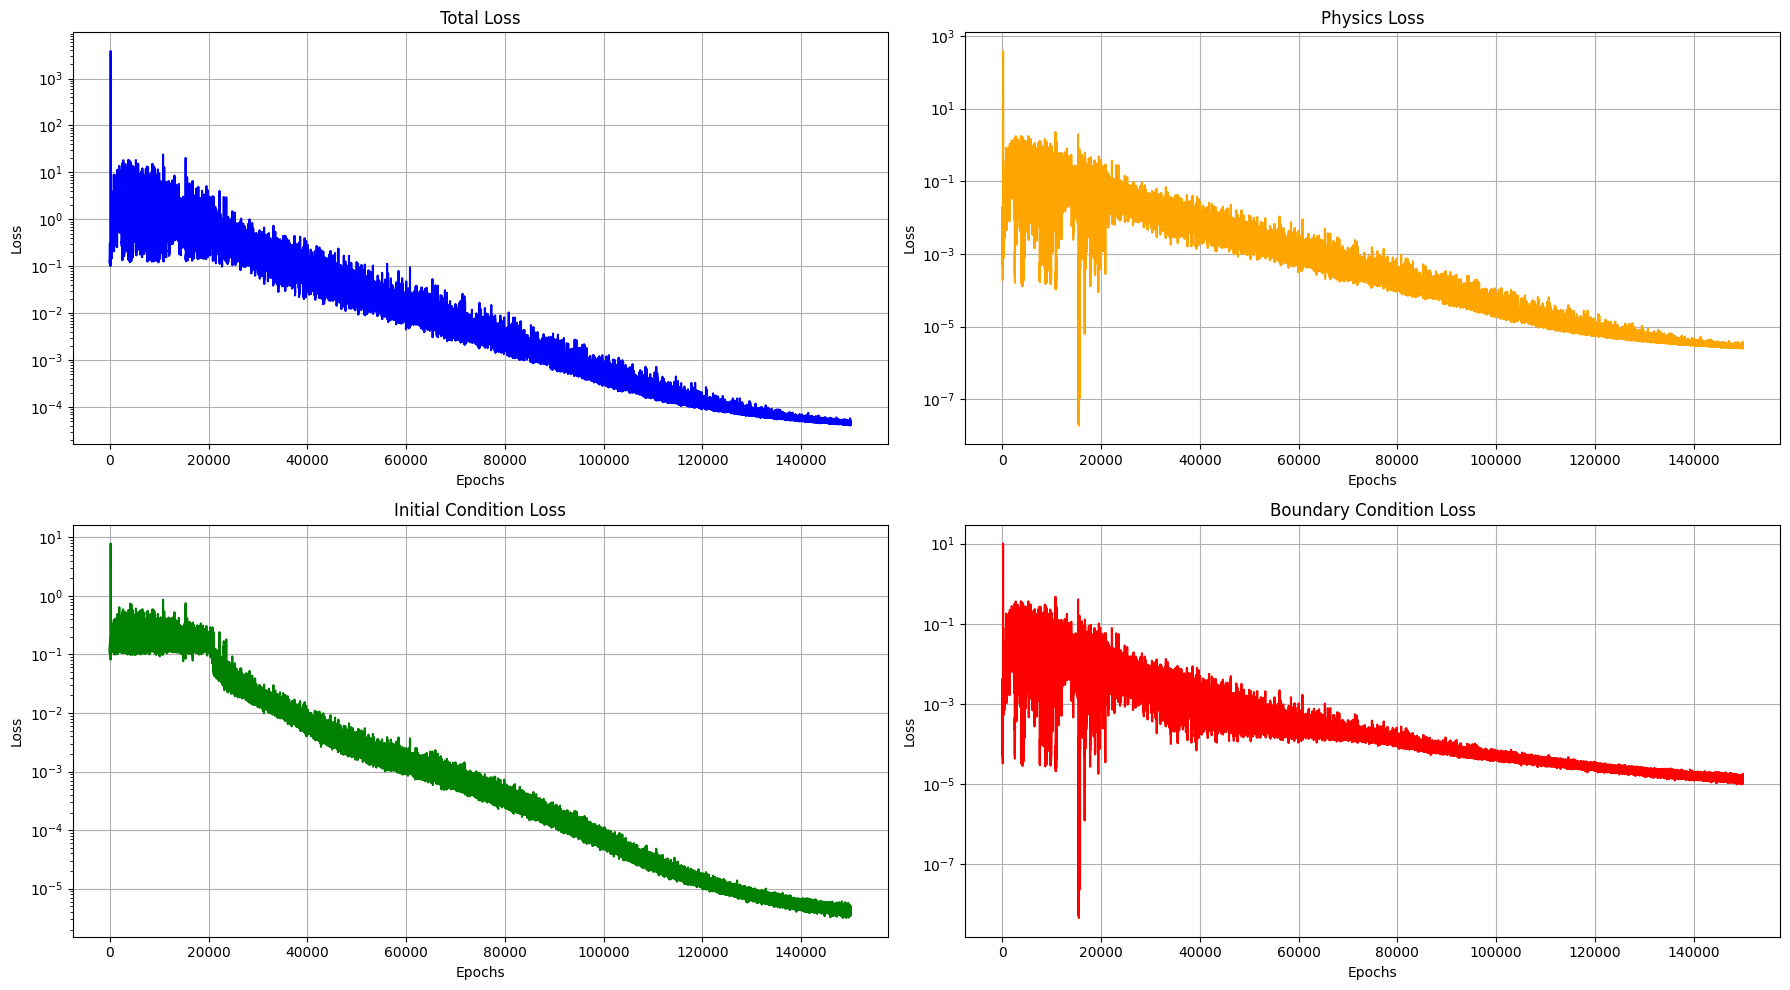

In [14]:
fig, axs = plt.subplots(2, 2, figsize=(18, 10))

# Total Loss
axs[0, 0].plot(epochs_range, total_loss_history, color='blue')
axs[0, 0].set_title('Total Loss')
axs[0, 0].set_xlabel('Epochs')
axs[0, 0].set_ylabel('Loss')
axs[0, 0].grid(True)
axs[0, 0].set_yscale("log")

# Physics Loss
axs[0, 1].plot(epochs_range, physics_loss_history, color='orange')
axs[0, 1].set_title('Physics Loss')
axs[0, 1].set_xlabel('Epochs')
axs[0, 1].set_ylabel('Loss')
axs[0, 1].grid(True)
axs[0, 1].set_yscale("log")

# Initial Condition Loss
axs[1, 0].plot(epochs_range, initial_condition_loss_history, color='green')
axs[1, 0].set_title('Initial Condition Loss')
axs[1, 0].set_xlabel('Epochs')
axs[1, 0].set_ylabel('Loss')
axs[1, 0].grid(True)
axs[1, 0].set_yscale("log")

# Boundary Condition Loss
axs[1, 1].plot(epochs_range, boundary_condition_loss_history, color='red')
axs[1, 1].set_title('Boundary Condition Loss')
axs[1, 1].set_xlabel('Epochs')
axs[1, 1].set_ylabel('Loss')
axs[1, 1].grid(True)
axs[1, 1].set_yscale("log")

plt.tight_layout()
plt.show()

### Testing
#### Since this is a relatively simpler problem, it has an analytical solution, as shown below. We will use this analytical solution to measure the performance of the PINN prediction

In [27]:
Nx = 628
Nt = 628

x_values = np.linspace(x_min, x_max, Nx)
t_values = np.linspace(t_min, t_max, Nt)

In [28]:
def analytical(x, t):
    A = (1 / np.sqrt(2)) * ((1 / np.pi) ** 0.25) * np.exp(-(x ** 2) / 2)
    B1 = np.exp(-1j * 0.5 * t)
    B2 = np.exp(-1j * 1.5 * t) * np.sqrt(2) * x
    return A * (B1 + B2)

In [29]:
psi_real_analytical = np.zeros((Nx, Nt), dtype=np.float64)
psi_img_analytical = np.zeros((Nx, Nt), dtype=np.float64)

for i, x in enumerate(x_values):
    for j, t in enumerate(t_values):
        psi_x_t = analytical(x, t)

        psi_real_analytical[i, j] = np.real(psi_x_t)
        psi_img_analytical[i, j] = np.imag(psi_x_t)

#### Analytical solution

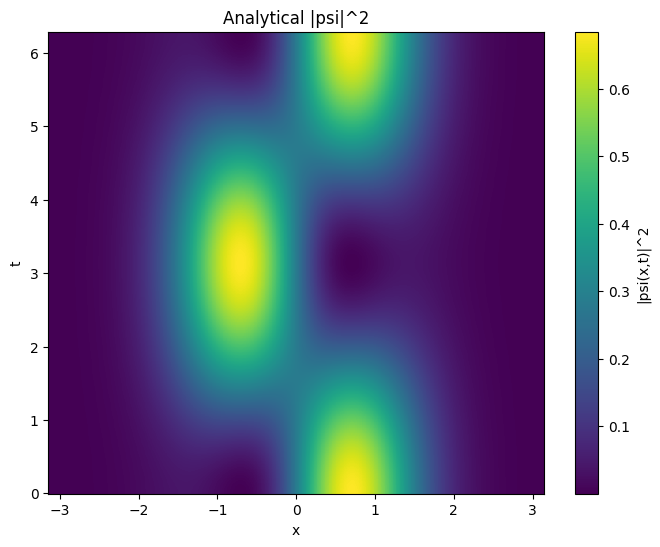

In [30]:
plt.figure(figsize=(8, 6))
psi_sq_analytical = psi_real_analytical ** 2 + psi_img_analytical ** 2

plt.pcolormesh(x_values, t_values, psi_sq_analytical.transpose(), shading="auto")
plt.colorbar(label='|psi(x,t)|^2')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Analytical |psi|^2')
plt.show()

In [31]:
x_values_torch = torch.from_numpy(x_values).float().to(device)
t_values_torch = torch.from_numpy(t_values).float().to(device)

x_grid, t_grid = torch.meshgrid(x_values_torch, t_values_torch, indexing="ij")

x_flat = torch.reshape(x_grid, [-1])
t_flat = torch.reshape(t_grid, [-1])

psi_real_pinn, psi_img_pinn = model((x_flat, t_flat))

psi_real_pinn = torch.reshape(psi_real_pinn, (Nx, Nt))
psi_img_pinn = torch.reshape(psi_img_pinn, (Nx, Nt))

psi_real_pinn = psi_real_pinn.detach().cpu().numpy()
psi_img_pinn = psi_img_pinn.detach().cpu().numpy()

#### PINN prediction

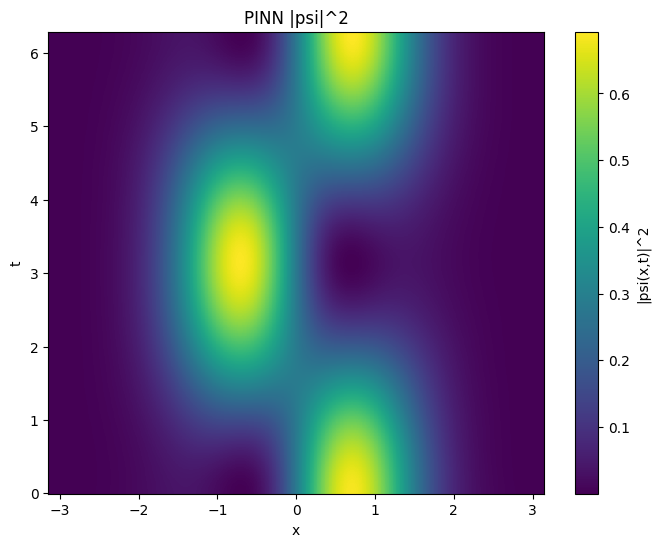

In [32]:
plt.figure(figsize=(8, 6))
psi_sq = psi_real_pinn ** 2 + psi_img_pinn ** 2

plt.pcolormesh(x_values, t_values, psi_sq.transpose(), shading="auto")
plt.colorbar(label='|psi(x,t)|^2')
plt.xlabel('x')
plt.ylabel('t')
plt.title('PINN |psi|^2')
plt.show()

#### Absolute difference between analytical and predicted solution

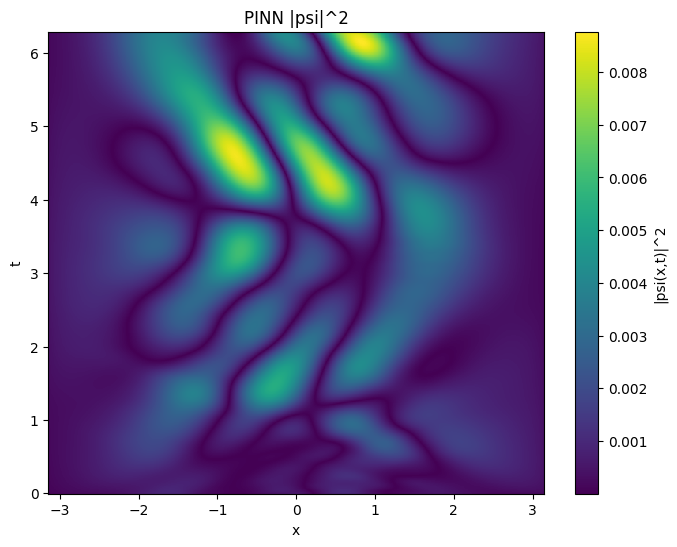

In [33]:
plt.figure(figsize=(8, 6))
psi_sq_diff = np.abs(psi_sq - psi_sq_analytical)

plt.pcolormesh(x_values, t_values, psi_sq_diff.transpose(), shading="auto")
plt.colorbar(label='|psi(x,t)|^2')
plt.xlabel('x')
plt.ylabel('t')
plt.title('PINN |psi|^2')
plt.show()

In [22]:
psi_analytical_mag = psi_real_analytical ** 2 + psi_img_analytical ** 2
psi_pinn_mag = psi_real_pinn ** 2 + psi_img_pinn ** 2

mse = (np.square(psi_analytical_mag - psi_pinn_mag)).mean()

print(f"Mean Squared Error: {mse:.3e}")

Mean Squared Error: 5.050e-06


#### Wavefunction normalization plot
- in theory, it is important that the wavefunction should stay normalized throught the time domain. in other words, the probability of finding a particle within space should stay at 1 at all the time
- checking the wavefunction normalization of our PINN solution can show how good our model is
- the closer it goes to 1, the better

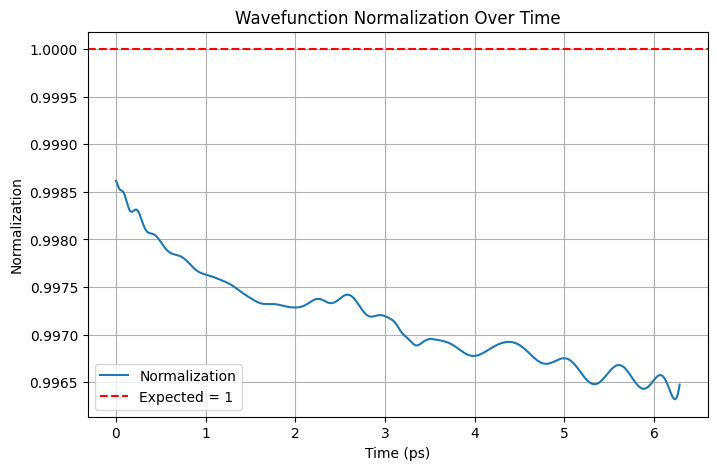

In [23]:
from scipy.integrate import simpson

norms = []

for i in range(628):
	psi_sq = psi_real_pinn[:, i] ** 2 + psi_img_pinn[:, i] ** 2
	normalization = simpson(psi_sq, x=x_values)
	norms.append(normalization)

plt.figure(figsize=(8,5))
plt.plot(t_values, norms, '-', label='Normalization')
plt.axhline(1.0, color='red', linestyle='--', label='Expected = 1')
plt.xlabel('Time (ps)')
plt.ylabel('Normalization')
plt.title('Wavefunction Normalization Over Time')
plt.legend()
plt.grid(True)
plt.show()